In [ ]:
# Cell for loading environment variables from config.py,
# which is located one directory above this notebook.
import sys
import os

current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.insert(0, parent_dir)

from config import set_environment
set_environment()

In [14]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_openai import ChatOpenAI
from langchain_core.prompts import PromptTemplate

In [ ]:
# llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")
llm = ChatOpenAI(model="gpt-4")

# ReACT example

Let's deep dive into the ReACT pattern and implement it ourselves. We will mock tools as simple Python functions (without actual implementation) for now:

In [37]:
import math

def mocked_google_search(query: str) -> str:
    print(f"CALLED GOOGLE_SEARCH with query={query}")
    return "Donald Trump is the current president of USA and he's 78 years old"


def mocked_calculator(expression: str) -> str:
    print(f"CALLED CALCULATOR with expression={expression}")
    if "sqrt" in expression:
        return math.sqrt(78*132)
    return 78*132

Let's define schemas for our tools and pass them to an LLM:

In [38]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

calculator_tool = {
    "type": "function",
    "function": {
        "name": "calculator",
        "description": "Computes mathematical expressions",
        "parameters": {
            "type": "object",
            "properties": {
                "expression": {
                    "type": "string",
                    "title": "expression",
                    "description": "A mathematical expression to be evaluated by a calculator",
                }
            },
            "required": ["expression"],
        },
    },
}

search_tool = {
    "type": "function",
    "function": {
        "name": "google_search",
        "description": "Returns about common facts, fresh events and news from Google Search engine based on a query.",
        "parameters": {
            "type": "object",
            "properties": {
                "query": {
                    "type": "string",
                    "title": "search_query",
                    "description": "Search query to be sent to the search engine",
                }
            },
            "required": ["query"],
        },
    },
}

system_prompt = (
    "Always use a calculator for mathematical computations, and use Google Search "
    "for information about common facts, fresh events and news. Do not assume anything, keep in "
    "mind that things are changing and always "
    "check yourself with external sources if possible."
)

from langchain_core.messages import SystemMessage

prompt = ChatPromptTemplate.from_messages(
    [SystemMessage(system_prompt), MessagesPlaceholder(variable_name="messages")]
)

In [39]:
llm_with_tools = prompt | llm.bind_tools([search_tool, calculator_tool])

Now it's time to define the LangGraph workflow itself.

In [40]:
# Imports
from langchain_core.messages import HumanMessage, ToolMessage
from langgraph.graph import START, END, MessagesState, StateGraph

def invoke_llm(state: MessagesState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

def call_tools(state: MessagesState):
    last_message = state["messages"][-1]
    tool_calls = last_message.tool_calls

    new_messages = []

    for tool_call in tool_calls:
        if tool_call["name"] == "google_search":
            tool_result = mocked_google_search(**tool_call["args"])
            new_messages.append(ToolMessage(content=tool_result, tool_call_id=tool_call["id"]))
        elif tool_call["name"] == "calculator":
            tool_result = mocked_calculator(**tool_call["args"])
            new_messages.append(ToolMessage(content=tool_result, tool_call_id=tool_call["id"]))
        else:
            raise ValueError(f"Tool {tool_call['name']} is not defined!")
    
    return {"messages": new_messages}
    

def should_run_tools(state: MessagesState):
    last_message = state["messages"][-1]
    if last_message.tool_calls:
        return "call_tools"
    return END

And we can put everything together as following:

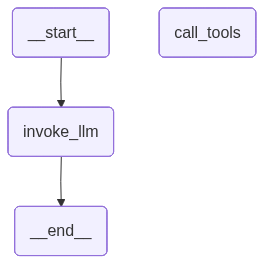

In [41]:
builder = StateGraph(MessagesState)
builder.add_node("invoke_llm", invoke_llm)
builder.add_node("call_tools", call_tools)

builder.add_edge(START, "invoke_llm")
builder.add_conditional_edges("invoke_llm", should_run_tools)
builder.add_edge("call_tools", "invoke_llm")
graph = builder.compile()

graph = builder.compile()

from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [42]:
question = "What is a square root of the current US president's age multiplied by 132?"

In [43]:
result = graph.invoke({"messages": [HumanMessage(question)]})
print(result["messages"][-1].content)

CALLED GOOGLE_SEARCH with query=current US president age
CALLED CALCULATOR with expression=sqrt(78) * 132
[{'type': 'text', 'text': "The square root of the current US president's age multiplied by 132 is approximately 101.47.", 'extras': {'signature': 'CvYBAXLI2nzVZaiDIikQSWaM5WpbBF7W3nntvaRl5dA+x0rc7CdT5SMLR1ex/tbd+jZzkU/wULMKIF4rzwh4owvAeqkSRMHHmV0HyCSGU6HtYSI4ZNbKUvfGAskx6KhrZqD2Zr6GjyCVqS2PQDWnlg+nYWUMzhgB+VJZUoG9Bc2E3Ml21EwslvJ4JGJE9ZneQ6yAIUaITxgskLR4QANFE6LoXzMSlFTYTHfQP4bFBjsNNc4xvwKofVK4ViCLdOhxkG6+L2+jyxdgCP33fH3tpuIEmS+JLJTsi13V0p67ezl2PkSGMhe4GMcV82R+E/SuIeYlh+3c4OOa'}}]


In [45]:
result

{'messages': [HumanMessage(content="What is a square root of the current US president's age multiplied by 132?", additional_kwargs={}, response_metadata={}, id='256556a0-f9d6-49c1-b000-a406abb9cd51'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'google_search', 'arguments': '{"query": "current US president age"}'}, '__gemini_function_call_thought_signatures__': {'52b68284-bc43-41e6-a463-1d3af28e597b': 'CqcFAXLI2nzgJ5mCA3HJztHPcPCiGuTb+u/TbbE0tsYhS006aiTjxvXGvFc+v50UYPSNUvHgRclKTMw1ZCMX8ZAiJZTwP3yVFLPbzJ3OHibavJ7//bcif4+W34L5ufFjIwxQbv50NnXlqdzC7zHLFdLAkeifni80tXuSjmQLyZs+EcgGtQpyw5Zife50rnziBymDsbaYgtfj1qEru/1I/INDh8CH/+uAyP8nVUy4vSQKwFI2nhM6/YxlPUOD7dAz2JAxMGcWExXILcGz9gqWzG15cPXDVY2umlYZeY9JVTEXifbO4bj7rpc5895QlEDNhwZH8nU0eG4Jkyw/AYwj7IXIAqfkQotHLWx37bLlWshNjdF+OlffbJ2moioKAd9eaYdtSc07Rn9U0h2W+RSkcM/I72kk2+5rxRUCv/aBgfNO01//lhRBS4iV+5RX+RXIo2d2QdvWzhspTwu/716amXiTEZjyTtrx0q2dEQzxKMjisSV+MGICNni/1Ro7zDOhvM5GelH6oUgGww3OpCQcmx6R62wBM7eRMFX1+3uYsJIqLZFNj8BGL4iiO

Now as you understand how it works under the hood, we can share good news with you. There's no need to implement it yourselves, you can use an customizable pre-built agent from LangGraph:

In [46]:
from langgraph.prebuilt import create_react_agent

agent = create_react_agent(model=llm, tools=[search_tool, calculator_tool], prompt=system_prompt)

In [48]:
agent.invoke({"messages": [HumanMessage(question)]})

{'messages': [HumanMessage(content="What is a square root of the current US president's age multiplied by 132?", additional_kwargs={}, response_metadata={}, id='4ae19cc3-087e-45fa-b9aa-39cf44e1f81c'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'google_search', 'arguments': '{"query": "current US president\'s age"}'}, '__gemini_function_call_thought_signatures__': {'5ff3face-0ac0-41a6-8db1-cc70288cb00f': 'CtACAXLI2nwL0zUb1+TGJ9SW+v1gIQbCOt1YeFPbiOPcFN0RJevwHb5GjVhwPmFd8CZCYH+7epsaD16qTnJvYl9/gcMRdvcx5IxsHNALNkIbMWBPIIEiaPU7kMaqDwZuUZxPiZbfV/T5tK8R1RI+KZbqalYMN1Lo46dBuY50OPXrm/G3KMhlpsQtd8I/CcPenbzkc0duGlB5ft7H4AsHyyFXyJkDtYit1boWFKc+liNCMy2vEJbrshbxycKYkGnxNobIAfsGTSbS6DPKfhUtKb3vsC5w3FmW6yVO4NLoOkASaG/P+dhrAvNk+4yjwZQxGbYX+mwbzosMwDZakiT5DpUWvuThZwMkUHRZGO5GVfBRaNaYaTNfqN1gXwyfGX1/TiJlZZtG5d5cbBJQhYiDTTLn6OCLr66ILhXO5F2zeGTYQvTIzbk99hmKg77nvlJf5UCJ'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_pr